In [1]:
# import necessary modules
# uncomment to get plots displayed in notebook
%matplotlib inline


### import class wrapper

from classy import Class

### math stuff
import numpy as np
from scipy.optimize import fsolve

### Controlling iteration speed

from tqdm.notebook import trange, tqdm 

### plotting stuff
import matplotlib.pyplot as plt
#import matplotlib.ticker as mticker
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import cmasher as cmr
import matplotlib.patheffects as pe
import matplotlib.ticker as ticker
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.ticker import FixedLocator, FixedFormatter
from scipy.interpolate import interp1d
from matplotlib.lines import Line2D
#import pandas as pd 

import itertools

# Enable LaTeX rendering
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath}" 
})



In [65]:
### INPUT ###
Omega_scf=1e-4 #scalar field density parameter at present, can be whatever as it's recomputed anyway, but needs to be sth for CLASS to realize there's scalar field.
k_values = [1e-3, 1e-2, 1e-1, 1]
k_values_CLASS = ', '.join([str(k) for k in k_values])
###
common_settings = {
                    'output': 'tCl,pCl,lCl,mPk',
                    'k_output_values': k_values_CLASS,
                    'lensing': 'yes',
                    'P_k_max_h/Mpc': 10, 
                    # LambdaCDM parameters
                   'h': 0.67810,
                   'omega_b': 0.02238280 ,
                   'Omega_chi': 0.27, # this is the dark matter density parameter
                   'Omega_cdm': 1e-5,
                   'Omega_Lambda': 0.70,
                   'Omega_k': 0,
                   #'gauge': 'new', 
                   ### let's add some massive neutrinos
                #    'N_ur': 0,
                #    'N_ncdm': 1, 
                #    'deg_ncdm': 3,
                #    'm_ncdm': 0.02, #eV
                #     'T_ncdm': 0.71611,
                   }  

no_scalar = { 
                  'output': 'tCl,pCl,lCl,mPk',
                  'k_output_values': k_values_CLASS,
                  'lensing': 'no',
                  'P_k_max_h/Mpc': 10, 
                  # LambdaCDM parameters
                  'h': 0.67810,
                  'omega_b': 0.02238280,
                  'Omega_cdm': 0.27,
                  #'Omega_Lambda': 0.72,
                  # 'Omega_k': 0.,
                  # 'Omega_scf': 0.,
                  # 'Omega_fld': 0., 
                  #'gauge': 'sync', 
                  #'beta': 0.0, 
                   }  

In [3]:
### Run CLASS ###
ScalarCLASS = {}
beta_lrm = [0.0, 0.005, 0.02]
s_ini_factor = [0, 1e2, 1e4, 1e6, 1e8]
s_ini = 1e-4
gauges = ['new', 'sync']
for gauge, beta in itertools.product(gauges, beta_lrm):
    if beta != 0.0:
        phi_prime_ini = 1 # WIP, just a rescaling of actual initial value
    else:
        phi_prime_ini = 0.0
    print(f'Running CLASS for beta = {beta} and phi_ini = {np.sqrt(beta/2)**(-1)*s_ini}, phi_prime_ini = {phi_prime_ini}') 
    ScalarCLASS[gauge, beta] = Class()
    ScalarCLASS[gauge, beta].set(common_settings)
    ScalarCLASS[gauge, beta].set({
                    'gauge': gauge,
                    'scf_parameters': f'0.0, 0.1, 0.0, 0.0, {s_ini}, {phi_prime_ini}',
                    'attractor_ic_scf': 'no',
                    'beta': beta,
                    'Omega_scf': Omega_scf,
                    })
    ScalarCLASS[gauge, beta].compute()
    
# Initialize dictionaries for background and perturbation quantities
bgScalar, pbScalar, thScalar = {}, {}, {}
z, a, H, a_th = {}, {}, {}, {}
phi_scf, dphi_scf, V_scf = {}, {}, {}
delta_chi, delta_cdm, theta_cdm, delta_g, delta_scf, delta_b = {}, {}, {}, {}, {}, {}
delta_m = {}
#theta_cdm, psi, phi = {}, {}, {}
rho_g, rho_cdm, rho_b, rho_ur, rho_scf, rho_lambda, rho_chi = {}, {}, {}, {}, {}, {}, {}
rho_ncdm = {}
frac_chi = {}
rho_tot, rho_crit = {}, {}
p_scf, comov = {}, {}
# Initialize dictionaries for power spectrum
ll, clTT, clEE, clTE, clPP = {}, {}, {}, {}, {}
ll_raw, clTT_raw, clEE_raw, clTE_raw, clPP_raw = {}, {}, {}, {}, {}
psi, phi = {}, {}
e_m_kappa, g = {}, {}
a_eq, z_rec = {}, {}

# Loop over each beta value and extract necessary background and perturbation data
for gauge, beta in itertools.product(gauges, beta_lrm):
    print(f'Extracting data for gauge = {gauge}, beta = {beta}')
    ### BACKGROUND
    bgScalar = ScalarCLASS[gauge, beta].get_background()
    a_eq[beta] = ScalarCLASS[gauge, beta].get_current_derived_parameters(['a_eq'])['a_eq']
    z_rec[beta] = ScalarCLASS[gauge, beta].get_current_derived_parameters(['z_rec'])['z_rec']
    thScalar = ScalarCLASS[gauge, beta].get_thermodynamics()

    a_th[gauge, beta] = thScalar['scale factor a']
    e_m_kappa[gauge, beta] = thScalar['exp(-kappa)']
    g[gauge, beta] = thScalar['g [Mpc^-1]']
    
    # Extract some background cosmological quantities
    H[gauge, beta] = bgScalar['H [1/Mpc]']
    z[gauge, beta] = bgScalar['z']
    comov[gauge, beta] = bgScalar['comov. dist.']

    # Extract energy densities for non-scalar components
    rho_g[gauge, beta] = bgScalar['(.)rho_g']
    rho_b[gauge, beta] = bgScalar['(.)rho_b']
    rho_chi[gauge, beta] = bgScalar['(.)rho_chi']
    rho_cdm[gauge, beta] = bgScalar['(.)rho_cdm']
    
    frac_chi[gauge, beta] = rho_chi[gauge, beta] / (rho_chi[gauge, beta] + rho_b[gauge, beta])
    
    rho_lambda[gauge, beta] = bgScalar['(.)rho_lambda']
    rho_ur[gauge, beta] = bgScalar['(.)rho_ur']
    rho_tot[gauge, beta] = bgScalar['(.)rho_tot']
    rho_crit[gauge, beta] = bgScalar['(.)rho_crit']
    
    # Extract scalar field quantities
    phi_scf[gauge, beta] = bgScalar['phi_scf']
    dphi_scf[gauge, beta] = bgScalar["phi'_scf"]
    V_scf[gauge, beta] = bgScalar['V_scf']
    rho_scf[gauge, beta] = bgScalar['(.)rho_scf']
    p_scf[gauge, beta] = bgScalar['(.)p_scf']
    
    ### PERTURBATIONS
    pbScalar = ScalarCLASS[gauge, beta].get_perturbations()
    for i in range(len(k_values)):
        scalar_data = pbScalar['scalar'][i]  # Scalar perturbations for selected k-values
        print(scalar_data.keys())
        a[gauge, beta, k_values[i]] = scalar_data['a']
        
        # Extract perturbation quantities
        delta_cdm[gauge, beta, k_values[i]] = scalar_data['delta_cdm']
        delta_chi[gauge, beta, k_values[i]] = scalar_data['delta_chi']
        delta_g[gauge, beta, k_values[i]] = scalar_data['delta_g']
        delta_scf[gauge, beta, k_values[i]] = scalar_data['delta_scf']
        delta_b[gauge, beta, k_values[i]] = scalar_data['delta_b']
        frac_chi_interp = np.interp(a[gauge, beta, k_values[i]], 1/(1+z[gauge, beta]), frac_chi[gauge, beta])
        delta_m[gauge, beta, k_values[i]] = frac_chi_interp*delta_cdm[gauge, beta, k_values[i]] + (1-frac_chi_interp)*delta_b[gauge, beta, k_values[i]]
        theta_cdm[gauge, beta, k_values[i]] = scalar_data['theta_cdm']
        psi[gauge, beta, k_values[i]] = scalar_data['psi']
        phi[gauge, beta, k_values[i]] = scalar_data['phi']
        
    ### POWER SPECTRUM
    
    clScalar_raw = ScalarCLASS[gauge, beta].raw_cl(2500)
    clScalar = ScalarCLASS[gauge, beta].lensed_cl(2500)
    ll[gauge, beta] = clScalar['ell'][2:]
    ll_raw[gauge, beta] = clScalar_raw['ell'][2:]
    clTT[gauge, beta] = clScalar['tt'][2:]
    clTT_raw[gauge, beta] = clScalar_raw['tt'][2:]
    clEE[gauge, beta] = clScalar['ee'][2:]
    clEE_raw[gauge, beta] = clScalar_raw['ee'][2:]
    clTE[gauge, beta] = clScalar['te'][2:]
    clTE_raw[gauge, beta] = clScalar_raw['te'][2:]
    clPP[gauge, beta] = clScalar['pp'][2:]
    clPP_raw[gauge, beta] = clScalar_raw['pp'][2:]
        


/tmp/ipykernel_118015/2193220668.py:12: RuntimeWarning: divide by zero encountered in scalar power
  print(f'Running CLASS for beta = {beta} and phi_ini = {np.sqrt(beta/2)**(-1)*s_ini}, phi_prime_ini = {phi_prime_ini}')


Running CLASS for beta = 0.0 and phi_ini = inf, phi_prime_ini = 0.0
[Iter 0] Omega0_lambda = 6.812216887286865e-01 (change = 1.681e+00)
Running CLASS for beta = 0.005 and phi_ini = 0.002, phi_prime_ini = 1
[Iter 0] Omega0_lambda = 6.892024029424242e-01 (change = 1.689e+00)
Running CLASS for beta = 0.02 and phi_ini = 0.001, phi_prime_ini = 1
[Iter 0] Omega0_lambda = 7.181774456816274e-01 (change = 1.718e+00)
Running CLASS for beta = 0.0 and phi_ini = inf, phi_prime_ini = 0.0
Running CLASS for beta = 0.005 and phi_ini = 0.002, phi_prime_ini = 1[Iter 0] Omega0_lambda = 6.812216887286865e-01 (change = 1.681e+00)

[Iter 0] Omega0_lambda = 6.892024029424242e-01 (change = 1.689e+00)
Running CLASS for beta = 0.02 and phi_ini = 0.001, phi_prime_ini = 1
Extracting data for gauge = new, beta = 0.0
[Iter 0] Omega0_lambda = 7.181774456816274e-01 (change = 1.718e+00)
dict_keys(['tau [Mpc]', 'a', 'delta_g', 'theta_g', 'shear_g', 'pol0_g', 'pol1_g', 'pol2_g', 'delta_b', 'theta_b', 'psi', 'phi', 'delta

In [67]:
LCDM = {}
bgLCDM, pbLCDM, thLCDM = {}, {}, {}
z_lcdm, H_lcdm = {}, {}
rho_cdm_lcdm, rho_b_lcdm, rho_g_lcdm, rho_lambda_lcdm, rho_ur_lcdm = {}, {}, {}, {}, {}
#rho_k_lcdm = {}
comov_lcdm = {}
frac_cdm = {}
frac_cdm_interp = {}
rho_tot_lcdm, rho_crit_lcdm = {}, {}
ll_lcdm, ll_raw_lcdm, clTT_lcdm, clEE_lcdm, clTE_lcdm, clPP_lcdm, clPP_raw_lcdm = {}, {}, {}, {}, {}, {}, {}
clTT_lcdm_raw, clEE_lcdm_raw, clTE_raw_lcdm = {}, {}, {}
delta_cdm_lcdm, delta_b_lcdm, theta_cdm_lcdm, delta_g_lcdm, a_lcdm = {}, {}, {}, {}, {}
delta_m_lcdm = {}
psi_lcdm, phi_lcdm = {}, {}

for gauge in gauges:
    LCDM[gauge] = Class()
    LCDM[gauge].set(no_scalar)
    LCDM[gauge].set({
                    'gauge': gauge,
                    })
    LCDM[gauge].compute()

    # Load LCDM background and perturbation data
    bgLCDM[gauge] = LCDM[gauge].get_background()
    a_eq_lcdm = LCDM[gauge].get_current_derived_parameters(['a_eq'])['a_eq']
    z_rec_lcdm = LCDM[gauge].get_current_derived_parameters(['z_rec'])['z_rec']
    pbLCDM[gauge] = LCDM[gauge].get_perturbations()
    thLCDM[gauge] = LCDM[gauge].get_thermodynamics()
    print(thLCDM[gauge].keys())

    # Extract LCDM background and perturbation quantities
    z_lcdm[gauge] = bgLCDM[gauge]['z']
    H_lcdm[gauge] = bgLCDM[gauge]['H [1/Mpc]']
    rho_cdm_lcdm[gauge] = bgLCDM[gauge]['(.)rho_cdm']
    rho_b_lcdm[gauge] = bgLCDM[gauge]['(.)rho_b']
    rho_g_lcdm[gauge] = bgLCDM[gauge]['(.)rho_g']
    rho_lambda_lcdm[gauge] = bgLCDM[gauge]['(.)rho_lambda']
    rho_ur_lcdm[gauge] = bgLCDM[gauge]['(.)rho_ur']
    #rho_k_lcdm = bgLCDM['(.)rho_scf']
    comov_lcdm[gauge] = bgLCDM[gauge]['comov. dist.']

    frac_cdm[gauge] = rho_cdm_lcdm[gauge]/(rho_cdm_lcdm[gauge] + rho_b_lcdm[gauge])

    for i in range(len(k_values)):
        scalar_data = pbLCDM[gauge]['scalar'][i]  # Scalar perturbations for selected k-values
        # Extract perturbation quantities
        a_lcdm[gauge, k_values[i]] = scalar_data['a']
        delta_cdm_lcdm[gauge, k_values[i]] = scalar_data['delta_cdm']
        theta_cdm_lcdm[gauge, k_values[i]] = scalar_data['theta_cdm']
        delta_b_lcdm[gauge, k_values[i]] = scalar_data['delta_b']
        
        frac_cdm_interp[gauge] = np.interp(a_lcdm[gauge, k_values[i]], 1/(1+z_lcdm[gauge]), frac_cdm[gauge])
        delta_m_lcdm[gauge, k_values[i]] = frac_cdm_interp[gauge] * delta_cdm_lcdm[gauge, k_values[i]] + (1-frac_cdm_interp[gauge]) * delta_b_lcdm[gauge, k_values[i]]
        
        delta_g_lcdm[gauge, k_values[i]] = scalar_data['delta_g']
        psi_lcdm[gauge, k_values[i]] = scalar_data['psi']
        phi_lcdm[gauge, k_values[i]] = scalar_data['phi']
        
    #clLCDM = LCDM[gauge].lensed_cl(2500)
    clLCDM_raw = LCDM[gauge].raw_cl(2500)
    #ll_lcdm[gauge] = clLCDM['ell'][2:]
    ll_raw_lcdm[gauge] = clLCDM_raw['ell'][2:]
    #clTT_lcdm[gauge] = clLCDM['tt'][2:]
    clTT_lcdm_raw[gauge] = clLCDM_raw['tt'][2:]
    #clEE_lcdm[gauge] = clLCDM['ee'][2:]
    clEE_lcdm_raw[gauge] = clLCDM_raw['ee'][2:]
    #clTE_lcdm[gauge] = clLCDM['te'][2:]
    clTE_raw_lcdm[gauge] = clLCDM_raw['te'][2:]
    #clPP_lcdm[gauge] = clLCDM['pp'][2:]
    clPP_raw_lcdm[gauge] = clLCDM_raw['pp'][2:]
        
    rho_tot_lcdm[gauge] = bgLCDM[gauge]['(.)rho_tot']
    rho_crit_lcdm[gauge] = bgLCDM[gauge]['(.)rho_crit']
    
    print(a_lcdm.keys())
    print(psi_lcdm.keys())


dict_keys(['scale factor a', 'z', 'conf. time [Mpc]', 'x_e', "kappa' [Mpc^-1]", 'exp(-kappa)', 'g [Mpc^-1]', 'Tb [K]', 'dTb [K]', 'w_b', 'c_b^2', 'tau_d'])
dict_keys([('new', 0.001), ('new', 0.01), ('new', 0.1), ('new', 1)])
dict_keys([('new', 0.001), ('new', 0.01), ('new', 0.1), ('new', 1)])


In [5]:
print(a_eq.keys())

dict_keys([0.0, 0.005, 0.02])


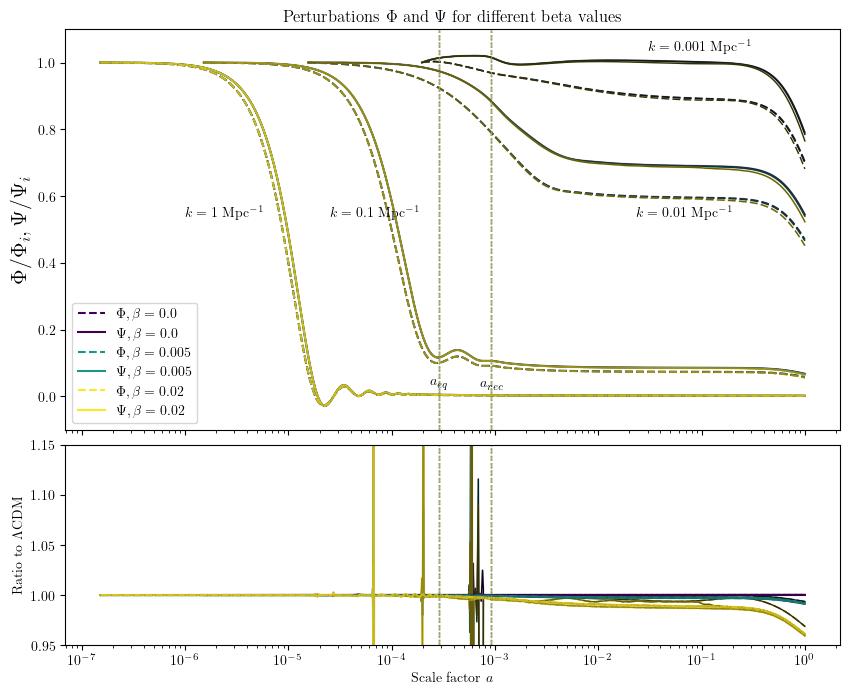

In [6]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patheffects as pe
import itertools
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.gridspec as gridspec

# Create subplots with shared x-axis
fig = plt.figure(figsize=(10, 8))
gs = gridspec.GridSpec(2, 1, height_ratios=[2, 1], hspace=0.05)
ax_main = fig.add_subplot(gs[0])
ax_ratio = fig.add_subplot(gs[1], sharex=ax_main)

#k = k_values[4]  # Choose a specific k value for plotting
beta_lrm = [0.0, 0.005, 0.02]
beta_colors = {beta: color for beta, color in zip(beta_lrm, plt.cm.viridis(np.linspace(0, 1, len(beta_lrm))))}
linestyles = {'new': '-', 'sync': '--'}
gauges = ['new']

# Interpolation for LCDM
psi_lcdm_interp = {}
phi_lcdm_interp = {}
for k in k_values:
    for gauge in gauges:
        psi_lcdm_interp[gauge, k] = interp1d(a_lcdm[gauge, k], psi_lcdm[gauge, k], kind='cubic', fill_value='extrapolate')
        phi_lcdm_interp[gauge, k] = interp1d(a_lcdm[gauge, k], phi_lcdm[gauge, k], kind='cubic', fill_value='extrapolate')

# Plot main curves
for i, k in enumerate(k_values):
    ### Define alpha for the current k value
    alpha = 0.2+i*0.2  # Adjust alpha as needed for visibility
    for gauge, beta in itertools.product(gauges, beta_lrm):
        a_vals = a[gauge, beta, k]
        psi_vals = psi[gauge, beta, k]
        phi_vals = phi[gauge, beta, k]

        ax_main.semilogx(a_vals, psi_vals/psi_vals[0], linestyle='-', color=beta_colors[beta], path_effects=[pe.Stroke(linewidth=1, foreground='black'), pe.Normal()], alpha=alpha)
        ax_main.semilogx(a_vals, phi_vals/phi_vals[0], linestyle='--', color=beta_colors[beta], path_effects=[pe.Stroke(linewidth=1, foreground='black'), pe.Normal()], alpha=alpha)
        

        # Calculate ratios
        psi_ratio = psi_vals / psi_lcdm_interp[gauge, k](a_vals)
        phi_ratio = phi_vals / phi_lcdm_interp[gauge, k](a_vals)

        ax_ratio.semilogx(a_vals, psi_ratio, linestyle='-', color=beta_colors[beta], path_effects=[pe.Stroke(linewidth=1, foreground='black'), pe.Normal()], alpha=alpha)
        ax_ratio.semilogx(a_vals, phi_ratio, linestyle='--', color=beta_colors[beta], path_effects=[pe.Stroke(linewidth=1, foreground='black'), pe.Normal()], alpha=alpha)
        

# Vertical lines
for ax in [ax_main, ax_ratio]:
    ax.vlines(a_eq_lcdm, -0.1, 1.5, color='black', linestyle=':', linewidth=1, alpha=0.5)
    ax.vlines(1/(1+z_rec_lcdm), -0.1, 1.5, color='black', linestyle=':', linewidth=1, alpha=0.5)
    for beta in beta_lrm:
        ax.vlines(a_eq[beta], -0.1, 1.5, color=beta_colors[beta], linestyle='--', linewidth=1, alpha=0.5)
        ax.vlines(1/(1+z_rec[beta]), -0.1, 1.5, color=beta_colors[beta], linestyle='--', linewidth=1, alpha=0.5)

# label the vertical lines
ax_main.text(a_eq_lcdm, 0.02, r'$a_{eq}$', color='black', fontsize=10, ha='center', va='bottom')
ax_main.text(1/(1+z_rec_lcdm), 0.02, r'$a_{rec}$', color='black', fontsize=10, ha='center', va='bottom')

ax_main.text(3e-1, 1.05, r'$k=0.001$ Mpc$^{-1}$', fontsize=10, color='xkcd:black', ha='right', va='center')
ax_main.text(2e-1, 0.55,  r'$k=0.01$ Mpc$^{-1}$', fontsize=10, color='xkcd:black', ha='right', va='center')
ax_main.text(2.5e-5, 0.55,  r'$k=0.1$ Mpc$^{-1}$', fontsize=10, color='xkcd:black', ha='left', va='center')
ax_main.text(1e-6, 0.55,  r'$k=1$ Mpc$^{-1}$', fontsize=10, color='xkcd:black', ha='left', va='center')


# Legend
handles = []
for beta in beta_lrm:
    handles.append(Line2D([0], [0], color=beta_colors[beta], linestyle='--', label=rf'$\Phi, \beta={beta}$'))
    handles.append(Line2D([0], [0], color=beta_colors[beta], linestyle='-', label=rf'$\Psi, \beta={beta}$'))
ax_main.legend(handles=handles, loc='lower left')

# Labels and limits
ax_main.set_ylim(-0.1, 1.1)
ax_main.set_ylabel(r'$\Phi/\Phi_i, \Psi/\Psi_i$', fontsize=16)
ax_main.set_title(r'Perturbations $\Phi$ and $\Psi$ for different beta values')

ax_ratio.set_ylabel(r'Ratio to $\Lambda$CDM')
ax_ratio.set_xlabel(r'Scale factor $a$')
ax_ratio.set_ylim(0.95, 1.15)  # Adjust as needed

# Hide x tick labels on top plot
plt.setp(ax_main.get_xticklabels(), visible=False)

plt.show()


/tmp/ipykernel_118015/1973194326.py:101: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


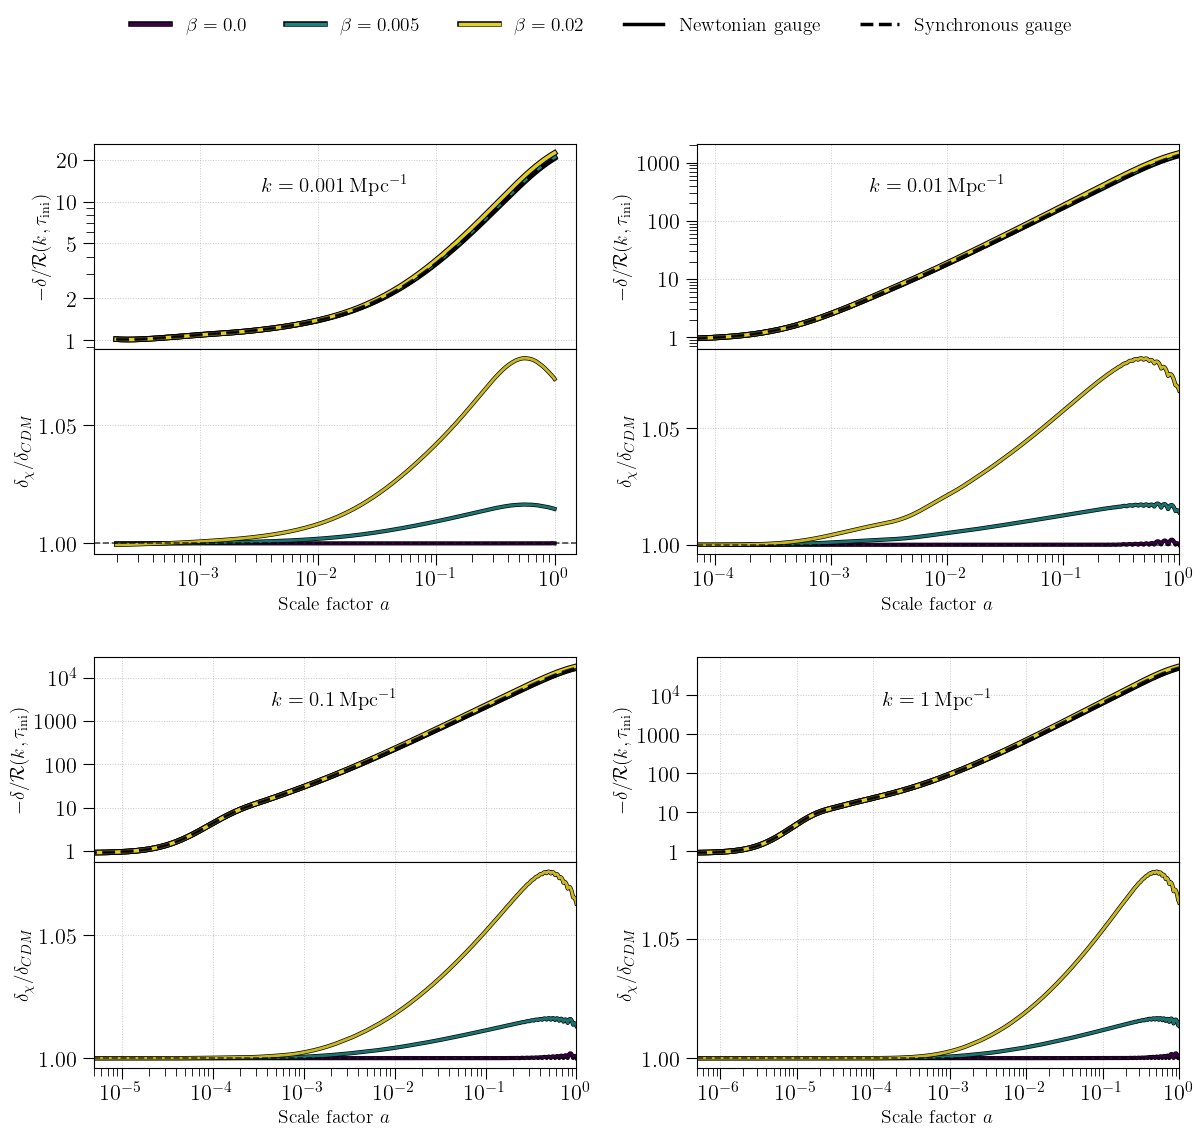

In [7]:
ks = k_values

fig = plt.figure(figsize=(14, 12))
outer = GridSpec(2, 2, wspace=0.25, hspace=0.25)

# Assign a unique color to each beta
beta_colors = {beta: color for beta, color in zip(beta_lrm, plt.cm.viridis(np.linspace(0, 1, len(beta_lrm))))}

for idx, k in enumerate(ks):
    row, col = divmod(idx, 2)
    inner = GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[idx], height_ratios=[2, 2], hspace=0.0)

    ax1 = fig.add_subplot(inner[0])
    ax2 = fig.add_subplot(inner[1], sharex=ax1)

    # Interpolation function for LCDM
    interp_lcdm = {
        gauge: interp1d(a_lcdm[gauge, k], delta_cdm_lcdm[gauge, k], kind='linear',
                        bounds_error=False, fill_value='extrapolate')
        for gauge in gauges
    }

    beta_legend_shown = set()

    for gauge, beta in itertools.product(gauges, beta_lrm):
        linestyle = '--' if gauge == 'sync' else '-'
        color = beta_colors[beta]

        # Plot delta_chi
        label = rf'$\beta = {beta}$' if beta not in beta_legend_shown else None
        ax1.loglog(a[gauge, beta, k], -delta_chi[gauge, beta, k],
                   label=label,
                   linewidth=2.5, path_effects=[pe.withStroke(linewidth=4, foreground='black')],
                   alpha=0.9, linestyle=linestyle, color=color)

        # Interpolate and plot LCDM
        delta_lcdm_interp = interp_lcdm[gauge](a[gauge, beta, k])
        ratio = delta_cdm[gauge, beta, k] / delta_lcdm_interp

        ax2.semilogx(a[gauge, beta, k], ratio,
                     linewidth=2.0, path_effects=[pe.withStroke(linewidth=3, foreground='black')],
                     alpha=0.8, linestyle=linestyle, color=color)

        if beta not in beta_legend_shown:
            beta_legend_shown.add(beta)

        # LCDM reference line
        ax1.loglog(a[gauge, beta, k], -delta_lcdm_interp,
                   linewidth=2.5, linestyle='--', alpha=0.8, color='black',
                   path_effects=[pe.withStroke(linewidth=1, foreground='black')])

    ax2.axhline(1, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
    ax1.grid(which='major', linestyle=':', linewidth=0.7, alpha=0.7)
    ax2.grid(which='major', linestyle=':', linewidth=0.7, alpha=0.7)

    if idx == 0:
        ax1.yaxis.set_major_locator(FixedLocator((1.0, 2.0, 5.0, 10, 20)))
        ax1.yaxis.set_major_formatter(FixedFormatter(['1', '2', '5', '10', '20']))
    if idx == 1:
        ax2.set_xlim(7e-5, 1)
        ax1.yaxis.set_major_locator(FixedLocator((1.0, 10.0, 100.0, 1000)))
        ax1.yaxis.set_major_formatter(FixedFormatter(['1', '10', '100', '1000']))
    if idx == 2:
        ax2.set_xlim(5e-6, 1)
        ax1.yaxis.set_major_locator(FixedLocator((1.0, 10.0, 100.0, 1000, 10000)))
        ax1.yaxis.set_major_formatter(FixedFormatter(['1', '10', '100', '1000', r'$10^4$']))
    if idx == 3:
        ax2.set_xlim(5e-7, 1)
        ax1.yaxis.set_major_locator(FixedLocator((1.0, 10.0, 100.0, 1000, 10000)))
        ax1.yaxis.set_major_formatter(FixedFormatter(['1', '10', '100', '1000', r'$10^4$']))

    ax1.tick_params(axis='x', which='both', labelbottom=False)
    ax1.tick_params(axis='both', which='major', labelsize=16, length=8)
    ax2.tick_params(axis='both', which='major', labelsize=16, length=8)
    ax1.tick_params(axis='both', which='minor', labelsize=16, length=6)
    ax2.tick_params(axis='both', which='minor', labelsize=16, length=6)
    ax2.yaxis.set_major_locator(FixedLocator((1.0, 1.05, 1.1, 1.15)))

    ax2.set_xlabel(r'Scale factor $a$', fontsize=14)
    ax1.set_ylabel(r'$-\delta/\mathcal{R}(k, \tau_\mathrm{ini})$', fontsize=14)
    ax2.set_ylabel(r'$\delta_\chi/\delta_{CDM}$', fontsize=14)

    ax1.text(0.5, 0.8, rf'$k = {k}\,\mathrm{{Mpc}}^{{-1}}$', fontsize=15,
             ha='center', va='center', transform=ax1.transAxes)

# Shared legend (colors for beta only)
handles, labels = ax1.get_legend_handles_labels()
# Custom legend handles for gauges
gauge_handles = [
    Line2D([0], [0], color='black', linestyle='-', linewidth=2.5, label='Newtonian gauge'),
    Line2D([0], [0], color='black', linestyle='--', linewidth=2.5, label='Synchronous gauge')
]

# Combine beta and gauge legend entries
all_handles = handles + gauge_handles
all_labels = labels + ['Newtonian gauge', 'Synchronous gauge']

fig.legend(all_handles, all_labels, loc='upper center', fontsize=14,
           ncol=len(beta_lrm) + 2, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('delta_cdm_2x2_diff_k_gauges.pdf', dpi=300, bbox_inches='tight')
plt.show()


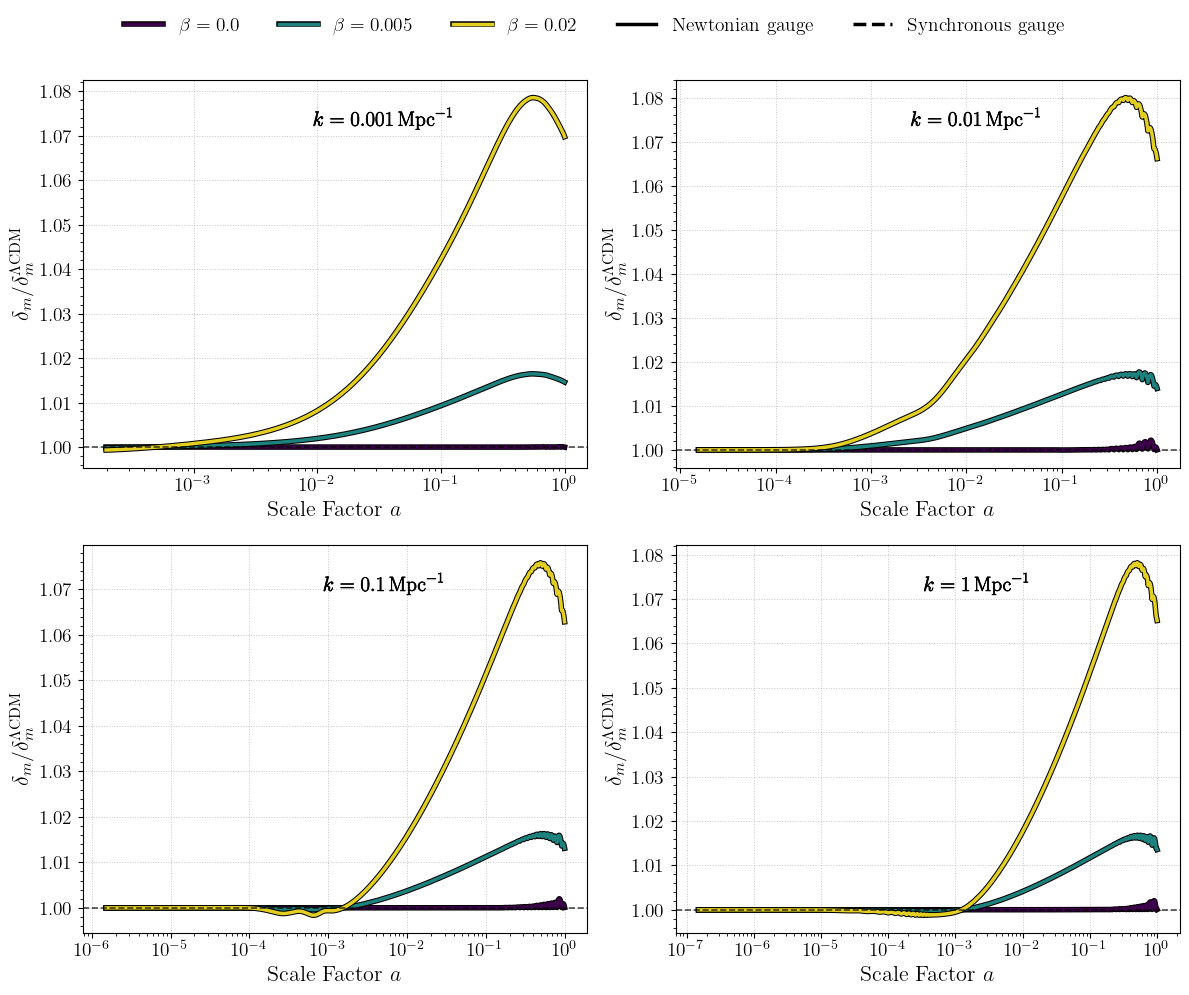

In [8]:
# Set up figure
fig, axs = plt.subplots(2, 2, figsize=(12, 10), sharex=False)
axs = axs.flatten()

# Assign consistent colors to each beta
beta_colors = {beta: color for beta, color in zip(beta_lrm, plt.cm.viridis(np.linspace(0, 1, len(beta_lrm))))}

for i, k in enumerate(k_values):
    for beta, gauge in itertools.product(beta_lrm, gauges):
        linestyle = '-' if gauge == 'new' else '--'
        color = beta_colors[beta]

        # Interpolate LCDM delta onto a[beta, k] grid
        interp_lcdm = interp1d(
            a_lcdm[gauge, k], delta_m_lcdm[gauge, k], 
            kind='linear', bounds_error=False, fill_value='extrapolate'
        )
        delta_m_interp = interp_lcdm(a[gauge, beta, k])
        
        # Compute the ratio
        ratio = delta_m[gauge, beta, k] / delta_m_interp
        
        # Plot
        axs[i].semilogx(
            a[gauge, beta, k],
            ratio,
            label=rf'$\beta = {beta}$' if gauge == 'new' else None,  # Avoid label duplication
            linewidth=2.5,
            linestyle=linestyle,
            color=color,
            alpha=0.9,
            path_effects=[pe.withStroke(linewidth=4, foreground='black')]
        )

# Format subplots
for i, ax in enumerate(axs):
    ax.set_ylabel(r'$\delta_m/\delta_m^{\Lambda\mathrm{CDM}}$', fontsize=16)
    ax.set_xlabel(r'Scale Factor $a$', fontsize=16)
    ax.grid(which='major', linestyle=':', linewidth=0.7, alpha=0.7)
    ax.minorticks_on()
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.axhline(y=1, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
    ax.text(0.6, 0.9, rf'$k = {k_values[i]}\,\mathrm{{Mpc}}^{{-1}}$', fontsize=15,
            ha='center', va='center', transform=ax.transAxes,
            path_effects=[pe.withStroke(linewidth=0.5, foreground='black')])
    ax.legend().remove()  # Remove individual subplot legends

# Create shared legend
handles, labels = axs[0].get_legend_handles_labels()
gauge_handles = [
    Line2D([0], [0], color='black', linestyle='-', linewidth=2.5, label='Newtonian gauge'),
    Line2D([0], [0], color='black', linestyle='--', linewidth=2.5, label='Synchronous gauge')
]
all_handles = handles + gauge_handles
all_labels = labels + ['Newtonian gauge', 'Synchronous gauge']

fig.legend(all_handles, all_labels, loc='upper center', fontsize=14, ncol=len(beta_lrm) + 2, frameon=False)

# Layout adjustments
plt.tight_layout()
plt.subplots_adjust(hspace=0.2, top=0.92)

# Save and show
fig.savefig('delta_m_diff_gauges.pdf', dpi=300, bbox_inches='tight')
plt.show()


In [15]:
print(gauges)

['new', 'sync']


/tmp/ipykernel_118015/1877624780.py:160: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


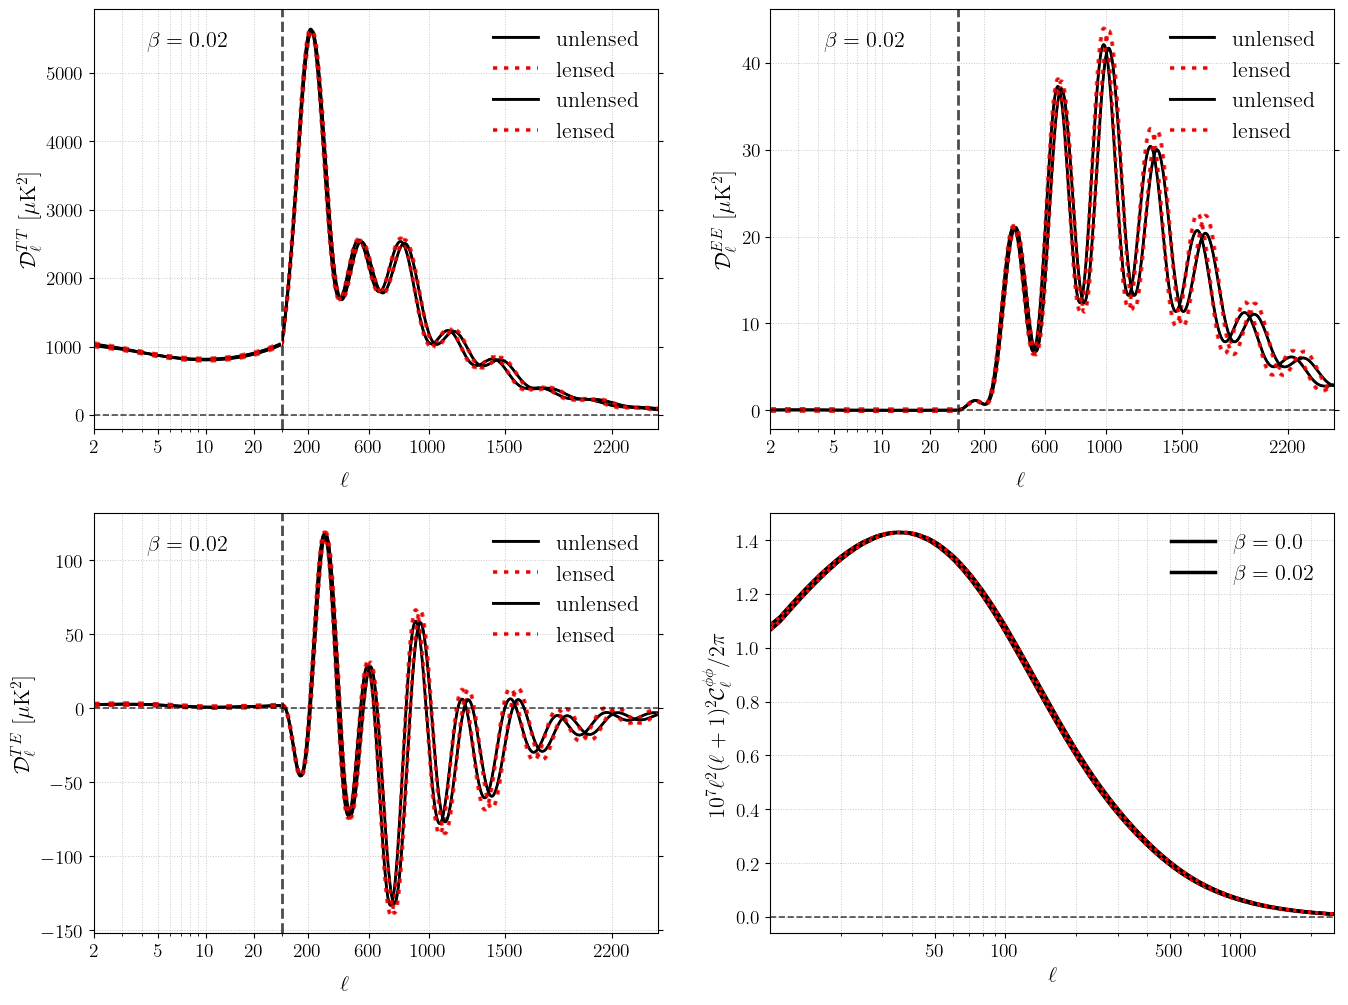

In [68]:
import matplotlib.gridspec as gridspec
from matplotlib.ticker import ScalarFormatter

### Plot the power spectra with split-axis approach
T0 = 2.7255  # CMB temperature in K

# Create figure with custom layout
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1], wspace=0.2, hspace=0.2)

beta_lrm = [0.0, 0.02]
gauges = ['new']

# Subplot configurations
subplot_configs = [
    (0, 'TT', clTT, r'$\mathcal{D}_\ell^{TT}$ [$\mu$K$^2$]', lambda cl, ell: cl*ell*(ell+1)/(2*np.pi)*1e12*T0**2, clTT_raw),
    (1, 'EE', clEE, r'$\mathcal{D}_\ell^{EE}$ [$\mu$K$^2$]', lambda cl, ell: cl*ell*(ell+1)/(2*np.pi)*1e12*T0**2, clEE_raw),
    (2, 'TE', clTE, r'$\mathcal{D}_\ell^{TE}$ [$\mu$K$^2$]', lambda cl, ell: cl*ell*(ell+1)/(2*np.pi)*1e12*T0**2, clTE_raw),
    (3, 'PP', clPP, r'$10^{7}\ell^2(\ell+1)^2\mathcal{C}_\ell^{\phi\phi}/2\pi$', lambda cl, ell: cl*(ell*(ell+1))**2/(2*np.pi)*1e7, clPP_raw)
]

# Custom plotting function for split-axis plots
def create_split_axis_subplot(fig, gs, row_col, ell, cl, label_func, ylabel, is_pp=False, ell_raw=None, cl_raw=None):
    # Create subplot grid
    if is_pp:
        # PP plot uses standard log scale
        ax = fig.add_subplot(gs[row_col])
        ax.set_xscale('log')
        ax.set_xlim(10, 2500)
        ax_log = ax
        # for gauge in gauges:
        #     linestyle = '--' if gauge == 'sync' else '-'
        #     ax.plot(ll_lcdm[gauge], clPP_lcdm[gauge]*(ll_lcdm[gauge]*(ll_lcdm[gauge]+1))**2/(2*np.pi)*1e7, linewidth=2, 
        #         label= rf'$\Lambda$CDM' if gauge == 'new' else None, 
        #         ls=linestyle, color = 'black', 
        #         path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])
        #     if ell_raw is not None and cl_raw is not None:
        #         ax.plot(ll_raw_lcdm[gauge], clPP_raw_lcdm[gauge]*(ll_raw_lcdm[gauge]*(ll_raw_lcdm[gauge]+1))**2/(2*np.pi)*1e7, 
        #                 linewidth=2, linestyle=linestyle, color = 'red', 
        #                 path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])
        for gauge, beta in itertools.product(gauges, beta_lrm):
            color = beta_colors[beta]
            linestyle = '-' if gauge == 'sync' else '-'
            ax.plot(ell[gauge, beta], cl[gauge, beta]*(ell[gauge, beta]*(ell[gauge, beta]+1))**2/(2*np.pi)*1e7, linewidth=2, 
                    label=rf'$\beta = {beta}$' if gauge == 'new' else None,
                    linestyle=linestyle,
                    path_effects=[pe.withStroke(linewidth=2.5, foreground='black')], color='black')
            if ell_raw is not None and cl_raw is not None:
                #color = 'xkcd:gray' if gauge == 'sync' else 'xkcd:blue'
                ax.plot(ell_raw[gauge, beta], cl_raw[gauge, beta]*(ell_raw[gauge, beta]*(ell_raw[gauge, beta]+1))**2/(2*np.pi)*1e7, 
                        linewidth=2, linestyle=':', color='red', 
                        path_effects=[pe.withStroke(linewidth=2.5, foreground='red')])
        ax.axhline(y=0, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
        ax.grid(which='both', linestyle=':', linewidth=0.7, alpha=0.7)
        ax.set_xlabel(r'$\ell$', fontsize=16)
        ax.set_ylabel(r'$10^{7}\ell^2(\ell+1)^2\mathcal{C}_\ell^{\phi\phi}/2\pi$', fontsize=16)
        ax.tick_params(axis='both', which='major', labelsize=14)
        ax.set_xticks([50, 100, 500, 1000])
        ax.get_xaxis().set_major_formatter(ScalarFormatter())
        return ax
    
    # Create GridSpec for split-axis plots
    gs_sub = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[row_col], 
                                               width_ratios=[1, 2], wspace=0.0)
    
    # Left subplot (log scale)
    ax_log = fig.add_subplot(gs_sub[0])
    ax_log.set_xscale('log')
    ax_log.set_xlim(2, 30)
    
    # Right subplot (linear scale)
    ax_lin = fig.add_subplot(gs_sub[1], sharey=ax_log)
    ax_lin.set_xlim(30, 2500)
    
    # Remove spines between the two plots
    ax_log.spines['right'].set_visible(False)
    ax_lin.spines['left'].set_visible(False)
    ax_log.yaxis.tick_left()
    ax_lin.yaxis.tick_right()

    # Plot spectra for each beta
    for gauge, beta in itertools.product(gauges, beta_lrm):
        # Prepare data masks
        mask_log = ell[gauge, beta] < 30
        mask_lin = ell[gauge, beta] >= 30
        if ell_raw is not None and cl_raw is not None:
            mask_log_raw = ell_raw[gauge, beta] < 30
            mask_lin_raw = ell_raw[gauge, beta] >= 30
        
        # Compute plotted values
        D_ell_log = label_func(cl[gauge, beta][mask_log], ell[gauge, beta][mask_log])
        D_ell_lin = label_func(cl[gauge, beta][mask_lin], ell[gauge, beta][mask_lin])
        if ell_raw is not None and cl_raw is not None:
            D_ell_raw_log = label_func(cl_raw[gauge, beta][mask_log_raw], ll_raw[gauge, beta][mask_log_raw])
            D_ell_raw_lin = label_func(cl_raw[gauge, beta][mask_lin_raw], ll_raw[gauge, beta][mask_lin_raw])
        
        color = beta_colors[beta]
        # Line properties
        line_kwargs = {
            'linewidth': 2, 
            'path_effects': [pe.withStroke(linewidth=1.5, foreground='black')],
            'label': rf'unlensed', 
            'color': 'black',
            'linestyle': '-' if gauge == 'sync' else '-'
        }
        
        # Plot on both axes
        ax_log.plot(ell[gauge, beta][mask_log], D_ell_log, **line_kwargs)
        ax_lin.plot(ell[gauge, beta][mask_lin], D_ell_lin, **line_kwargs)
        linestyle = ':' 
        if ell_raw is not None and cl_raw is not None:
            color = 'xkcd:red'
            ax_log.plot(ll_raw[gauge, beta][mask_log_raw], D_ell_raw_log, 
                        linewidth=4, linestyle=linestyle, color=color, 
                        path_effects=[pe.withStroke(linewidth=1.5, foreground='red')], alpha=0.7)
            ax_lin.plot(ll_raw[gauge, beta][mask_lin_raw], D_ell_raw_lin, 
                        linewidth=3, linestyle=linestyle, color=color, 
                        path_effects=[pe.withStroke(linewidth=1.5, foreground='red')], alpha=0.7, label='lensed')
    
    # Formatting
    ax_log.set_ylabel(ylabel, fontsize=16)
    ax_lin.set_xlabel(r'$\ell$', fontsize=16)
    ax_lin.xaxis.set_label_coords(1/6, -0.1)
    for ax in [ax_log, ax_lin]:
        ax.grid(which='both', linestyle=':', linewidth=0.7, alpha=0.7)
        ax.axhline(y=0, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
        ax.axvline(x=30, color='black', linestyle='--', linewidth=2, alpha=0.7)
        ax.tick_params(axis='both', which='major', labelsize=14)
    
    # Tick formatting
    ax_log.set_xticks([2, 5, 10, 20])
    ax_lin.set_xticks([200, 600, 1000, 1500, 2200])
    for ax in [ax_log, ax_lin]:
        ax.get_xaxis().set_major_formatter(ScalarFormatter())
    
    # Tick visibility
    ax_log.tick_params(labelleft=True, labelright=False)
    ax_lin.tick_params(labelleft=False, labelright=False)
    ax_log.text(0.5, 0.9, rf'$\beta={beta}$', fontsize=16, ha='center', va='bottom', transform=ax_log.transAxes)
    
    # Legend
    ax_lin.legend(fontsize=16, loc='upper right', frameon=False)
    
    return ax_log, ax_lin

# Create subplots
for (idx, name, cl_dict, ylabel, label_func, cl_dict_raw) in subplot_configs:
    is_pp = (name == 'PP')
    if is_pp:
        # PP plot is different (standard log scale)
        ax = create_split_axis_subplot(fig, gs, idx, ll, cl_dict, label_func, ylabel, is_pp=True, ell_raw=ll_raw, cl_raw=cl_dict_raw)
        ax.legend(fontsize=16, loc='upper right', frameon=False)
    else:
        # TT, EE, TE plots use split-axis
        create_split_axis_subplot(fig, gs, idx, ll, cl_dict, label_func, ylabel, is_pp=False, ell_raw=ll_raw, cl_raw=cl_dict_raw)
        
fig.savefig(f'power_spectra_lensing_{gauges[0]}.pdf', dpi=300, bbox_inches='tight')


plt.tight_layout()
plt.show()

In [10]:
print(gauges)

['new']


/tmp/ipykernel_118015/2579639897.py:126: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_log.legend(fontsize=16, loc='upper left', frameon=False)
/tmp/ipykernel_118015/2579639897.py:70: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=16, loc='upper right', frameon=False)
/tmp/ipykernel_118015/2579639897.py:140: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


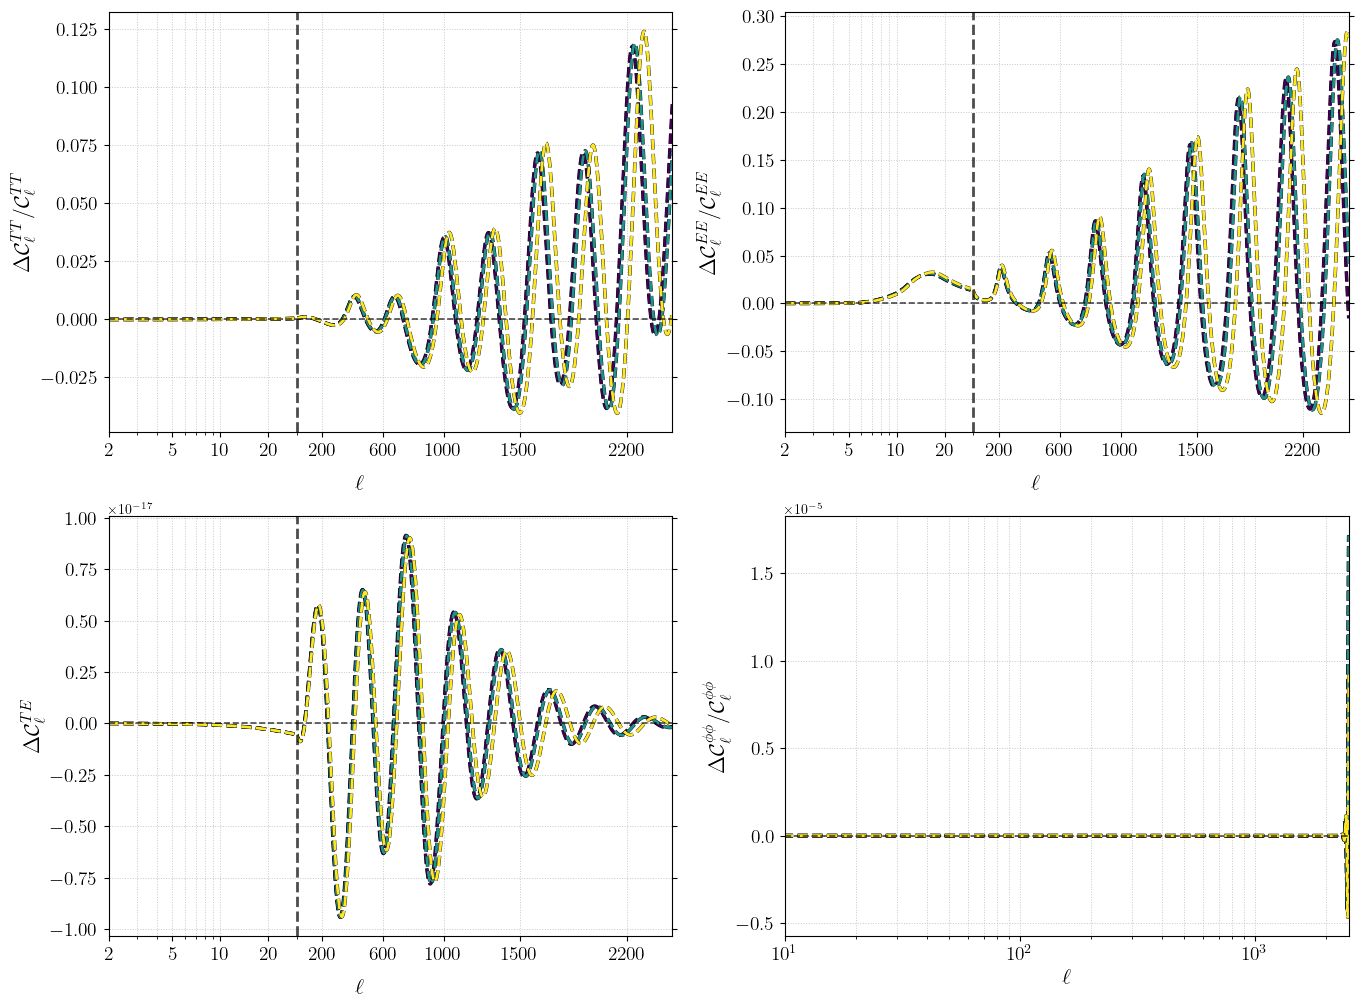

In [45]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import ScalarFormatter
import itertools
import matplotlib.patheffects as pe

# Constants
T0 = 2.7255  # CMB temperature in K
beta_lrm = [0.0, 0.005, 0.02]
gauges = ['sync']
split_ell_threshold = 30

# Plot configuration
figsize = (16, 12)
xticks_log = [2, 5, 10, 20]
xticks_lin = [200, 600, 1000, 1500, 2200]
xticks_pp = [50, 100, 500, 1000]

# Subplot info: (index, label, data_dict, y-axis label, transform_func, raw_data_dict)
subplot_configs = [
    (0, 'TT', clTT, r'$\Delta\mathcal{C}_\ell^{TT}/\mathcal{C}_\ell^{TT}$', lambda cl, cl_raw: (cl - cl_raw) / cl_raw, clTT_raw),
    (1, 'EE', clEE, r'$\Delta\mathcal{C}_\ell^{EE}/\mathcal{C}_\ell^{EE}$', lambda cl, cl_raw: (cl - cl_raw) / cl_raw, clEE_raw),
    (2, 'TE', clTE, r'$\Delta\mathcal{C}_\ell^{TE}$', lambda cl, cl_raw: (cl - cl_raw), clTE_raw),
    (3, 'PP', clPP, r'$\Delta\mathcal{C}_\ell^{\phi\phi}/\mathcal{C}_\ell^{\phi\phi}$', lambda cl, cl_raw: (cl - cl_raw) / cl_raw, clPP_raw),
]

# Create figure and GridSpec layout
fig = plt.figure(figsize=figsize)
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1], wspace=0.2, hspace=0.2)

def plot_common_lines(ax, ell, cl, cl_raw, label_func, ylabel, is_log=False):
    for gauge, beta in itertools.product(gauges, beta_lrm):
        color = beta_colors[beta]
        style = '--' if gauge == 'sync' else '-'
        label = rf'$\beta = {beta}$' if gauge == 'new' else None
        diff = label_func(cl[gauge, beta], cl_raw[gauge, beta])
        ax.plot(ell[gauge, beta], diff,
                linewidth=2,
                linestyle=style,
                color=color,
                label=label,
                path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])
    ax.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
    ax.set_ylabel(ylabel, fontsize=16)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.grid(which='both', linestyle=':', linewidth=0.7, alpha=0.7)
    ax.get_xaxis().set_major_formatter(ScalarFormatter())
    if is_log:
        ax.set_xscale('log')

def create_pp_subplot(fig, gs, index, ell, cl, label_func, ylabel, cl_raw):
    ax = fig.add_subplot(gs[index])
    ax.set_xlim(10, 2500)
    ax.set_xscale('log')
    ax.set_xticks(xticks_pp)

    # Plot LCDM reference
    for gauge in gauges:
        style = '--' if gauge == 'sync' else '-'
        ax.plot(ll_lcdm[gauge],
                (clPP_lcdm[gauge] - clPP_raw_lcdm[gauge]) / clPP_raw_lcdm[gauge],
                linewidth=2,
                linestyle=style,
                color='black',
                label=r'$\Lambda$CDM' if gauge == 'new' else None,
                path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])

    plot_common_lines(ax, ell, cl, cl_raw, label_func, ylabel, is_log=True)
    ax.set_xlabel(r'$\ell$', fontsize=16)
    ax.legend(fontsize=16, loc='upper right', frameon=False)
    return ax

def create_split_subplot(fig, gs, index, ell, cl, label_func, ylabel, cl_raw):
    gs_sub = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[index], width_ratios=[1, 2], wspace=0.0)
    ax_log = fig.add_subplot(gs_sub[0])
    ax_lin = fig.add_subplot(gs_sub[1], sharey=ax_log)

    # Plot formatting
    ax_log.set_xlim(2, split_ell_threshold)
    ax_log.set_xscale('log')
    ax_log.set_xticks(xticks_log)
    ax_lin.set_xlim(split_ell_threshold, 2500)
    ax_lin.set_xticks(xticks_lin)

    # Hide spines and sync axes
    ax_log.spines['right'].set_visible(False)
    ax_lin.spines['left'].set_visible(False)
    ax_log.yaxis.tick_left()
    ax_lin.yaxis.tick_right()

    # Plot data
    for gauge, beta in itertools.product(gauges, beta_lrm):
        color = beta_colors[beta]
        style = '--' if gauge == 'sync' else '-'
        label = rf'$\beta = {beta}$' if gauge == 'new' else None

        mask_log = ell[gauge, beta] < split_ell_threshold
        mask_lin = ell[gauge, beta] >= split_ell_threshold

        diff_log = label_func(cl[gauge, beta][mask_log], cl_raw[gauge, beta][mask_log])
        diff_lin = label_func(cl[gauge, beta][mask_lin], cl_raw[gauge, beta][mask_lin])

        line_kwargs = {
            'linewidth': 2,
            'linestyle': style,
            'color': color,
            'label': label,
            'path_effects': [pe.withStroke(linewidth=2.5, foreground='black')]
        }

        ax_log.plot(ell[gauge, beta][mask_log], diff_log, **line_kwargs)
        ax_lin.plot(ell[gauge, beta][mask_lin], diff_lin, **line_kwargs)

    for ax in [ax_log, ax_lin]:
        ax.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
        ax.axvline(split_ell_threshold, color='black', linestyle='--', linewidth=2, alpha=0.7)
        ax.grid(which='both', linestyle=':', linewidth=0.7, alpha=0.7)
        ax.tick_params(axis='both', which='major', labelsize=14)
        ax.get_xaxis().set_major_formatter(ScalarFormatter())

    ax_log.set_ylabel(ylabel, fontsize=16)
    ax_lin.set_xlabel(r'$\ell$', fontsize=16)
    ax_lin.xaxis.set_label_coords(1/6, -0.1)
    ax_log.tick_params(labelleft=True, labelright=False)
    ax_lin.tick_params(labelleft=False, labelright=False)
    ax_log.legend(fontsize=16, loc='upper left', frameon=False)

    return ax_log, ax_lin

# Build all subplots
for idx, name, cl_dict, ylabel, label_func, cl_dict_raw in subplot_configs:
    is_pp = (name == 'PP')
    if is_pp:
        create_pp_subplot(fig, gs, idx, ll, cl_dict, label_func, ylabel, cl_dict_raw)
    else:
        create_split_subplot(fig, gs, idx, ll, cl_dict, label_func, ylabel, cl_dict_raw)

# Save and display
fig.savefig(f'lensing_diff_{gauges[0]}.pdf', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


/tmp/ipykernel_105828/3464063740.py:116: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


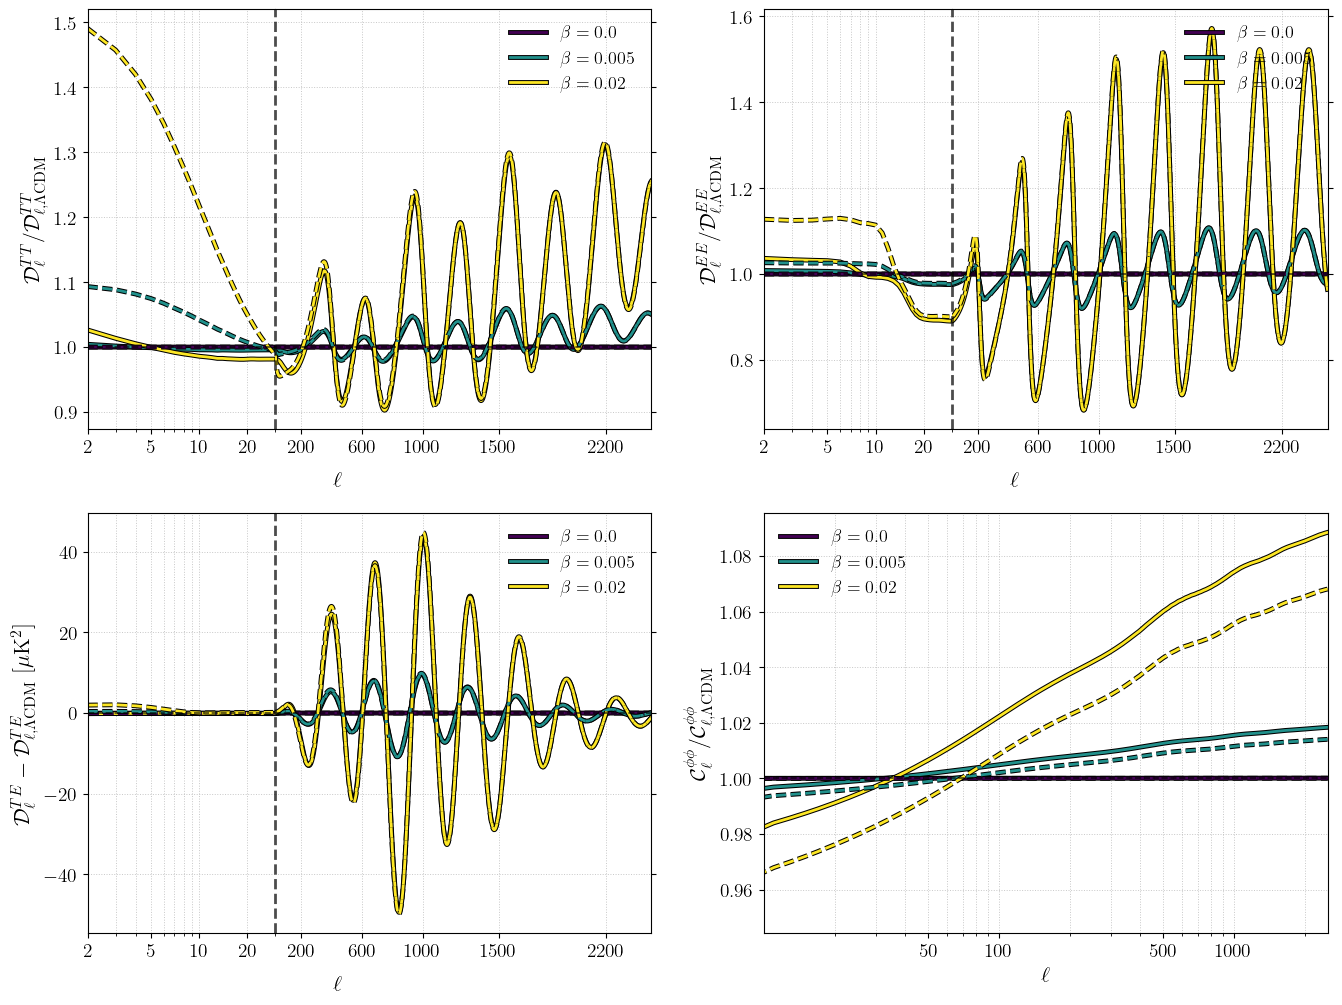

In [ ]:
import matplotlib.gridspec as gridspec
from matplotlib.ticker import ScalarFormatter

T0 = 2.7255  # CMB temperature in K

# Create figure with custom layout
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1], wspace=0.2, hspace=0.2)

# Plot configurations
subplot_configs = [
    (0, 'TT', clTT, clTT_lcdm, r'$\mathcal{D}_\ell^{TT}/\mathcal{D}_{\ell, \Lambda \mathrm{CDM}}^{TT}$', lambda cl, cl_lcdm: cl / cl_lcdm),
    (1, 'EE', clEE, clEE_lcdm, r'$\mathcal{D}_\ell^{EE}/\mathcal{D}_{\ell, \Lambda \mathrm{CDM}}^{EE}$', lambda cl, cl_lcdm: cl / cl_lcdm),
    (2, 'TE', clTE, clTE_lcdm, r'$\mathcal{D}_\ell^{TE} - \mathcal{D}_{\ell, \Lambda \mathrm{CDM}}^{TE}$ [$\mu$K$^2$]', lambda cl, cl_lcdm, ell: (cl - cl_lcdm) * ell * (ell + 1) / (2 * np.pi) * 1e12 * T0**2),
    (3, 'PP', clPP, clPP_lcdm, r'$\mathcal{C}_\ell^{\phi\phi}/\mathcal{C}_{\ell, \Lambda \mathrm{CDM}}^{\phi\phi}$', lambda cl, cl_lcdm: cl / cl_lcdm)
]

# Main plotting function (now includes gauge)
def create_split_axis_subplot(fig, gs, row_col, ell, cl, cl_lcdm, label_func, ylabel, is_pp=False, is_te=False, idx=None):
    if is_pp:
        ax = fig.add_subplot(gs[row_col])
        ax.set_xscale('log')
        ax.set_xlim(10, 2500)

        for gauge in gauges:
            for beta in beta_lrm:
                color = beta_colors[beta]
                ax.plot(ell[gauge, beta], label_func(cl[gauge, beta], cl_lcdm[gauge]), linewidth=2,
                        label=rf'$\beta = {beta}$' if gauge == 'new' else None,
                        linestyle='-' if gauge == 'new' else '--',
                        path_effects=[pe.withStroke(linewidth=3.5, foreground='black')], 
                        color=color)
        
        ax.axhline(y=1, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
        ax.grid(which='both', linestyle=':', linewidth=0.7, alpha=0.7)
        ax.set_xlabel(r'$\ell$', fontsize=16)
        ax.set_ylabel(ylabel, fontsize=16)
        ax.tick_params(axis='both', which='major', labelsize=14)
        ax.set_xticks([50, 100, 500, 1000])
        ax.get_xaxis().set_major_formatter(ScalarFormatter())
        ax.legend(fontsize=13, loc='upper left', frameon=False)
        return ax

    gs_sub = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[row_col], width_ratios=[1, 2], wspace=0.0)
    ax_log = fig.add_subplot(gs_sub[0])
    ax_lin = fig.add_subplot(gs_sub[1], sharey=ax_log)

    ax_log.set_xscale('log')
    ax_log.set_xlim(2, 30)
    ax_lin.set_xlim(30, 2500)

    ax_log.spines['right'].set_visible(False)
    ax_lin.spines['left'].set_visible(False)
    ax_log.yaxis.tick_left()
    ax_lin.yaxis.tick_right()

    for gauge in gauges:
        for beta in beta_lrm:
            color = beta_colors[beta]
            mask_log = ell[gauge, beta] < 30
            mask_lin = ell[gauge, beta] >= 30

            if is_te:
                D_ell_log = label_func(cl[gauge, beta][mask_log], cl_lcdm[gauge][mask_log], ell[gauge, beta][mask_log])
                D_ell_lin = label_func(cl[gauge, beta][mask_lin], cl_lcdm[gauge][mask_lin], ell[gauge, beta][mask_lin])
            else:
                D_ell_log = label_func(cl[gauge, beta][mask_log], cl_lcdm[gauge][mask_log])
                D_ell_lin = label_func(cl[gauge, beta][mask_lin], cl_lcdm[gauge][mask_lin])

            line_kwargs = {
                'linewidth': 2,
                'path_effects': [pe.withStroke(linewidth=3.5, foreground='black')],
                'label': rf'$\beta = {beta}$' if gauge == 'new' else None,
                'color': color,
                'linestyle': '-' if gauge == 'new' else '--'
            }

            ax_log.plot(ell[gauge, beta][mask_log], D_ell_log, **line_kwargs)
            ax_lin.plot(ell[gauge, beta][mask_lin], D_ell_lin, **line_kwargs)

    ax_log.set_ylabel(ylabel, fontsize=16)
    ax_lin.set_xlabel(r'$\ell$', fontsize=16)
    ax_lin.xaxis.set_label_coords(1 / 6, -0.1)

    for ax in [ax_log, ax_lin]:
        ax.grid(which='both', linestyle=':', linewidth=0.7, alpha=0.7)
        ax.axvline(x=30, color='black', linestyle='--', linewidth=2, alpha=0.7)
        if is_te:
            ax.axhline(y=0, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
        else:
            ax.axhline(y=1, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
        ax.tick_params(axis='both', which='major', labelsize=14)

    ax_log.set_xticks([2, 5, 10, 20])
    ax_lin.set_xticks([200, 600, 1000, 1500, 2200])
    for ax in [ax_log, ax_lin]:
        ax.get_xaxis().set_major_formatter(ScalarFormatter())

    ax_log.tick_params(labelleft=True, labelright=False)
    ax_lin.tick_params(labelleft=False, labelright=False)

    ax_lin.legend(fontsize=13, loc='upper right', frameon=False)

    return ax_log, ax_lin

# Create all subplots
for (idx, name, cl_dict, cl_lcdm_dict, ylabel, label_func) in subplot_configs:
    is_pp = (name == 'PP')
    is_te = (name == 'TE')
    if is_pp:
        create_split_axis_subplot(fig, gs, idx, ll, cl_dict, cl_lcdm_dict, label_func, ylabel, is_pp=True, idx=idx)
    else:
        create_split_axis_subplot(fig, gs, idx, ll, cl_dict, cl_lcdm_dict, label_func, ylabel, is_te=is_te, idx=idx)

fig.savefig('power_spectra_ratios_diff_gauges.pdf', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


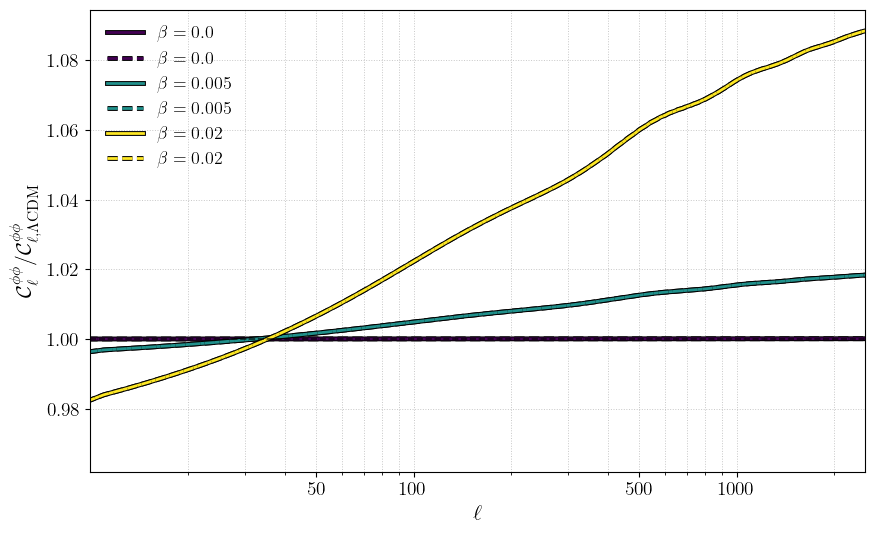

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xscale('log')
ax.set_xlim(10, 2500)

gauges = ['new']
for gauge in gauges:
    for beta in beta_lrm:
        color = beta_colors[beta]
        ax.plot(ll[gauge, beta], label_func(clPP[gauge, beta], clPP_lcdm[gauge]), linewidth=2,
                label=rf'$\beta = {beta}$' if gauge == 'new' else None,
                linestyle='-' if gauge == 'new' else '--',
                path_effects=[pe.withStroke(linewidth=3.5, foreground='black')], 
                color=color)
        ax.plot(ll_raw[gauge, beta], label_func(clPP_raw[gauge, beta], clPP_raw_lcdm[gauge]), linewidth=2,
                label=rf'$\beta = {beta}$' if gauge == 'new' else None,
                linestyle='--' if gauge == 'new' else '-',
                path_effects=[pe.withStroke(linewidth=3.5, foreground='black')], 
                color=color)

ax.axhline(y=1, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
ax.grid(which='both', linestyle=':', linewidth=0.7, alpha=0.7)
ax.set_xlabel(r'$\ell$', fontsize=16)
ax.set_ylabel(ylabel, fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_xticks([50, 100, 500, 1000])
ax.get_xaxis().set_major_formatter(ScalarFormatter())
ax.legend(fontsize=13, loc='upper left', frameon=False)
